In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Summary_of_Results_3_18_2026.csv')
df.head()

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR
0,13797.0,NM,"TAYLOR, NE",1653.0,5/31/1985,2466,1000,BANK OF TAYLOR,14542.0,13360.0,FAILURE,PA,FDIC
1,18388.0,NM,"FAIRFIELD, NE",1656.0,5/31/1985,6571,1001,FAIRFIELD STATE BANK,6795.0,6034.0,FAILURE,PO,FDIC
2,18738.0,NM,"EDGAR, NE",1118.0,5/31/1985,2469,1002,SECURITY STATE BANK,6570.0,6072.0,FAILURE,PA,FDIC
3,19117.0,NM,"OAK, NE",165.0,5/31/1985,6570,1003,SCROGGIN & COMPANY BANK,3552.0,3219.0,FAILURE,PO,FDIC
4,30965.0,SL,"SAN DIEGO, CA",327146.0,5/31/1985,1706,1004,CENTRAL S&LA,2308903.0,1680711.0,ASSISTANCE,A/A,FSLIC


# Phase 1: Basic Data Cleaning

In [3]:
print(f"Initial size : {df.shape[0]} banks.")

Initial size : 3592 banks.


In [4]:
# How many missing COST before cleaning?
print(df['COST'].isna().sum())

# Drop rows with missing COST or cost =0
df = df.dropna(subset=['COST'])
df = df[df['COST'] != 0]  

df = df[df['QBFASSET'] > 0] #security to divide 

116


In [5]:
# Convert FAILDATE to datetime
df['FAILDATE'] = pd.to_datetime(df['FAILDATE'], errors='coerce')


In [6]:
#Check if there are rows with non-positive Assets
(df['QBFASSET'] <= 0).sum()

np.int64(0)

In [7]:
# Drop rows with missing values
df = df.dropna(subset=['COST', 'QBFASSET', 'QBFDEP', 'FAILDATE'])

print(f"size after base cleaning : {df.shape[0]} banques.")

size after base cleaning : 3386 banques.


# Phase 2: Target & Feature Engineering

In [8]:
# Create the Target Veriable LGD = COST/ QBFASSET
df['LGD'] = df['COST'] / df['QBFASSET']
df['LGD'].describe()


count    3386.000000
mean        0.264111
std         0.326121
min        -0.200323
25%         0.103878
50%         0.203590
75%         0.323671
max        10.871010
Name: LGD, dtype: float64

In [9]:
#Create Financial Ratio Feature
df['Deposit_to_Asset_Ratio'] = df['QBFDEP'] / df['QBFASSET']
df['Deposit_to_Asset_Ratio'].describe()


count    3386.000000
mean        0.960200
std         0.215023
min         0.000000
25%         0.894479
50%         0.956275
75%         1.001830
max         8.897978
Name: Deposit_to_Asset_Ratio, dtype: float64

In [10]:
#Create the Spatial/Temporal Feature -
#How many banks in the same state failed in the 365 days before this bank’s failure.
df = df.sort_values('FAILDATE')

df['STATE'] = df['CITYST'].str[-2:]

df['State_Failures_Last_12M'] = 0

for i in range(len(df)):
    current_state = df.iloc[i]['STATE']
    current_date = df.iloc[i]['FAILDATE']
    window_start = current_date - pd.Timedelta(days=365)
    
    count = df[
        (df['STATE'] == current_state) &
        (df['FAILDATE'] < current_date) &
        (df['FAILDATE'] >= window_start)
    ].shape[0]
    
    df.at[df.index[i], 'State_Failures_Last_12M'] = count


# New features: 
US Unemployment Rate : https://fred.stlouisfed.org/series/UNRATE

FED rate: https://fred.stlouisfed.org/data/FEDFUNDS





In [11]:
unemp = pd.read_csv('US_unemployment_rate.csv')
fed_rate = pd.read_csv('avg Federal Funds Effective Rate.csv')

In [12]:
unemp.head()

,observation_date,UNRATE
0,1/01/1976,7.7
1,1/01/1977,7.1
2,1/01/1978,6.1
3,1/01/1979,5.9
4,1/01/1980,7.2


In [13]:
unemp['observation_date'] = pd.to_datetime(unemp['observation_date'])
unemp['YEAR'] = unemp['observation_date'].dt.year  #extracting the year 

annual_unemp = unemp.groupby('YEAR')['UNRATE'].mean().reset_index()  #mean of unemployment by year
annual_unemp = annual_unemp.dropna()
print(annual_unemp)
#UNRATE: unemployment rate 

    YEAR  UNRATE
0   1976    7.70
1   1977    7.10
2   1978    6.10
3   1979    5.90
4   1980    7.20
5   1981    7.60
6   1982    9.70
7   1983    9.60
8   1984    7.50
9   1985    7.20
10  1986    7.00
11  1987    6.20
12  1988    5.50
13  1989    5.30
14  1990    5.60
15  1991    6.90
16  1992    7.50
17  1993    6.90
18  1994    6.10
19  1995    5.60
20  1996    5.40
21  1997    4.90
22  1998    4.50
23  1999    4.20
24  2000    4.00
25  2001    4.70
26  2002    5.80
27  2003    6.00
28  2004    5.50
29  2005    5.10
30  2006    4.60
31  2007    4.60
32  2008    5.80
33  2009    9.30
34  2010    9.60
35  2011    8.90
36  2012    8.10
37  2013    7.40
38  2014    6.20
39  2015    5.30
40  2016    4.90
41  2017    4.40
42  2018    3.90
43  2019    3.70
44  2020    8.10
45  2021    5.40
46  2022    3.70
47  2023    3.60
48  2024    4.00
49  2025    4.26
50  2026    4.35


In [14]:
fed_rate.head()

,DATE,VALUE
0,1/07/1954,0.80
1,1/08/1954,1.22
2,1/09/1954,1.07
3,1/10/1954,0.85
4,1/11/1954,0.83


In [15]:
fed_rate['DATE'] = pd.to_datetime(fed_rate['DATE'])
fed_rate['YEAR'] = fed_rate['DATE'].dt.year

annual_fed = fed_rate.groupby('YEAR')['VALUE'].mean().reset_index()
annual_fed.rename(columns={'VALUE': 'FEDFUNDS'}, inplace=True)
print(annual_fed.head())

   YEAR  FEDFUNDS
0  1954  1.008333
1  1955  1.785000
2  1956  2.728333
3  1957  3.105000
4  1958  1.572500


In [16]:
df['YEAR'] = df['FAILDATE'].dt.year  #extracting the year to merge with the unrate
df = df.merge(annual_unemp, on='YEAR', how='left')
df = df.merge(annual_fed, on='YEAR', how='left')


### Phase 3: Prepare Data for ML models

### **Definitely drop:**
- **CERT** → ID number, no predictive meaning  
- **FIN** → internal FDIC ID, useless  
- **ID** → internal dataset ID  
- **NAME** → bank name (categorical noise, too many unique values)  
- **CITYST** → replaced by **STATE**  
- **RESTYPE** → always “FAILURE”, zero variance  
- **FAILDATE** → replaced by **YEAR**  

- **COST** → already converted to LGD  



In [17]:
cols_to_drop = [
    'CERT', 'FIN', 'ID', 'NAME', 'CITYST', 
    'RESTYPE', 'FAILDATE', 'COST'
]

df = df.drop(columns=cols_to_drop)


In [18]:
categorical_cols = ['CHCLASS1', 'RESTYPE1', 'SAVR', 'STATE']
numerical_cols = [
    'QBFASSET', 'QBFDEP', 'Deposit_to_Asset_Ratio',
    'State_Failures_Last_12M', 'YEAR', 'UNRATE', 'FEDFUNDS'
]
target = 'LGD'


In [19]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [20]:
#Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])


In [21]:
#Final dataset ready for modeling
X = df_encoded.drop(columns=[target])
y = df_encoded[target]
print(X.shape, y.shape)

(3386, 78) (3386,)


In [22]:
#---------Base dataset model--------
new_columns= ['UNRATE', 'FEDFUNDS', 'State_Failures_Last_12M', 'Deposit_to_Asset_Ratio', 'YEAR']
X_baseline=X.drop(columns=new_columns)

In [23]:
print(f"Baseline model features count: {X_baseline.shape[1]}")
print(f"Enriched model features count: {X.shape[1]}")

Baseline model features count: 73
Enriched model features count: 78


In [24]:
from sklearn.model_selection import train_test_split
#Splitting the enriched dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Splitting the base dataset
X_train_base, X_test_base,_,_= train_test_split(X_baseline, y, test_size=0.2, random_state=42)

In [25]:
results = []

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
#base model
lr_base= LinearRegression()
lr_base.fit(X_train_base,y_train)
pred_base=lr_base.predict(X_test_base)

results.append({
    'Model': 'Linear Regression Base Model',
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_base)),
    'R2': r2_score(y_test, pred_base)
})

In [28]:
#full model 
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

results.append({
    'Model': 'Linear Regression Enriched model',
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [29]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

In [30]:
#base model
ridge_base= GridSearchCV(Ridge(),ridge_params,cv=5)
ridge_base.fit(X_train_base,y_train)
pred_base= ridge_base.predict(X_test_base)

results.append({
    'Model': 'Ridge BM',  #BM for Base Model
    'Best Params': str(ridge_base.best_params_),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_base)),
    'R2': r2_score(y_test, pred_base)
})

In [31]:
#enriched model
ridge = GridSearchCV(Ridge(), ridge_params, cv=5)  #cross validation=5
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

results.append({
    'Model': 'Ridge EM', #EM for Enriched Model
    'Best Params': ridge.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [32]:
from sklearn.linear_model import Lasso
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

In [33]:
#base model
lasso_base=GridSearchCV(Lasso(max_iter=5000),lasso_params,cv=5)
lasso_base.fit(X_train_base,y_train)
pred_base=lasso_base.predict(X_test_base)

results.append({
    'Model': 'Lasso BM',
    'Best Params': str(lasso_base.best_params_),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_base)),
    'R2': r2_score(y_test, pred_base)
})

In [34]:

lasso = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5)
lasso.fit(X_train, y_train)
pred = lasso.predict(X_test)

results.append({
    'Model': 'Lasso EM',
    'Best Params': lasso.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [35]:
from sklearn.ensemble import RandomForestRegressor
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

In [36]:
#base model 
rf_base=GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3)
rf_base.fit(X_train_base,y_train)
pred_base=rf_base.predict(X_test_base)

results.append({
    'Model': 'Random Forest BM',
    'Best Params': str(rf_base.best_params_),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_base)),
    'R2': r2_score(y_test, pred_base)
})

In [37]:
#enriched model
rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

results.append({
    'Model': 'Random Forest EM',
    'Best Params': rf.best_params_,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    'R2': r2_score(y_test, pred)
})

In [38]:
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2,Best Params
0,Linear Regression Base Model,0.223914,0.219351,NaN
1,Linear Regression Enriched model,0.188758,0.445239,NaN
2,Ridge BM,0.224679,0.214003,{'alpha': 10}
3,Ridge EM,0.188559,0.446406,{'alpha': 1}
4,Lasso BM,0.223793,0.220194,{'alpha': 0.0001}
5,Lasso EM,0.188515,0.446668,{'alpha': 0.0001}
6,Random Forest BM,0.186659,0.457509,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
7,Random Forest EM,0.148687,0.655776,"{'max_depth': 20, 'min_samples_split': 2, 'n_e..."


 Our findings show that the Enriched Random Forest is the top-performing model, achieving an R2 of 0.6558. By adding macroeconomic features, we boosted predictive accuracy by 20 points compared to the Baseline . This significant improvement proves that external economic context is a critical driver of bank failure costs (LDG), reducing our prediction error (RMSE) by 20%. 

--- LINEAR REGRESSION ---


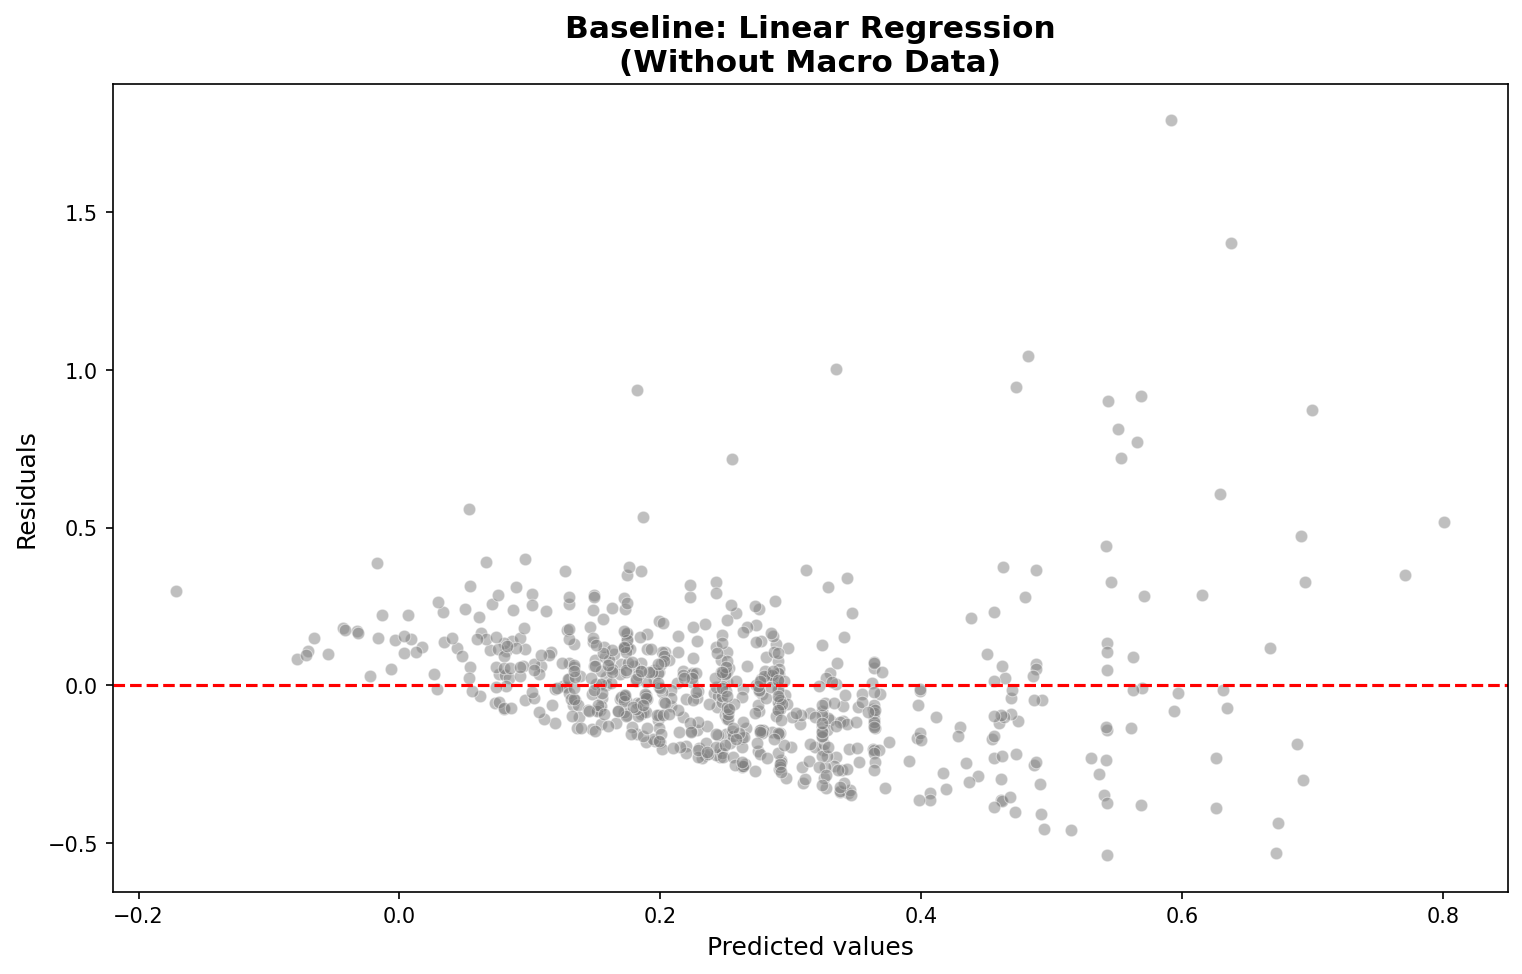

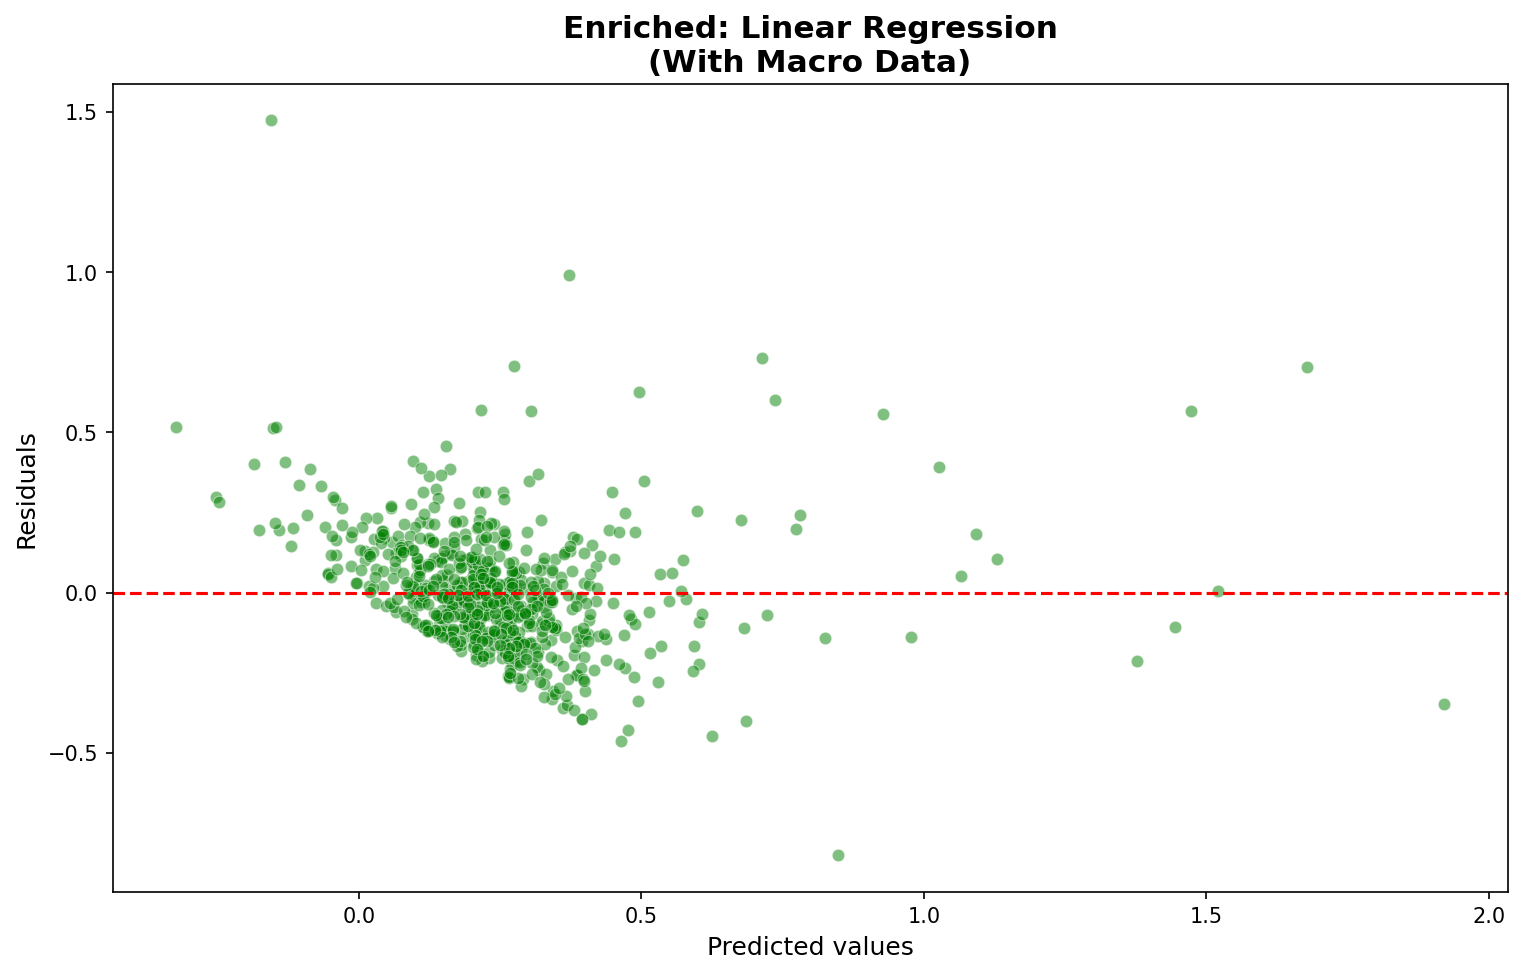

--- RIDGE REGRESSION ---


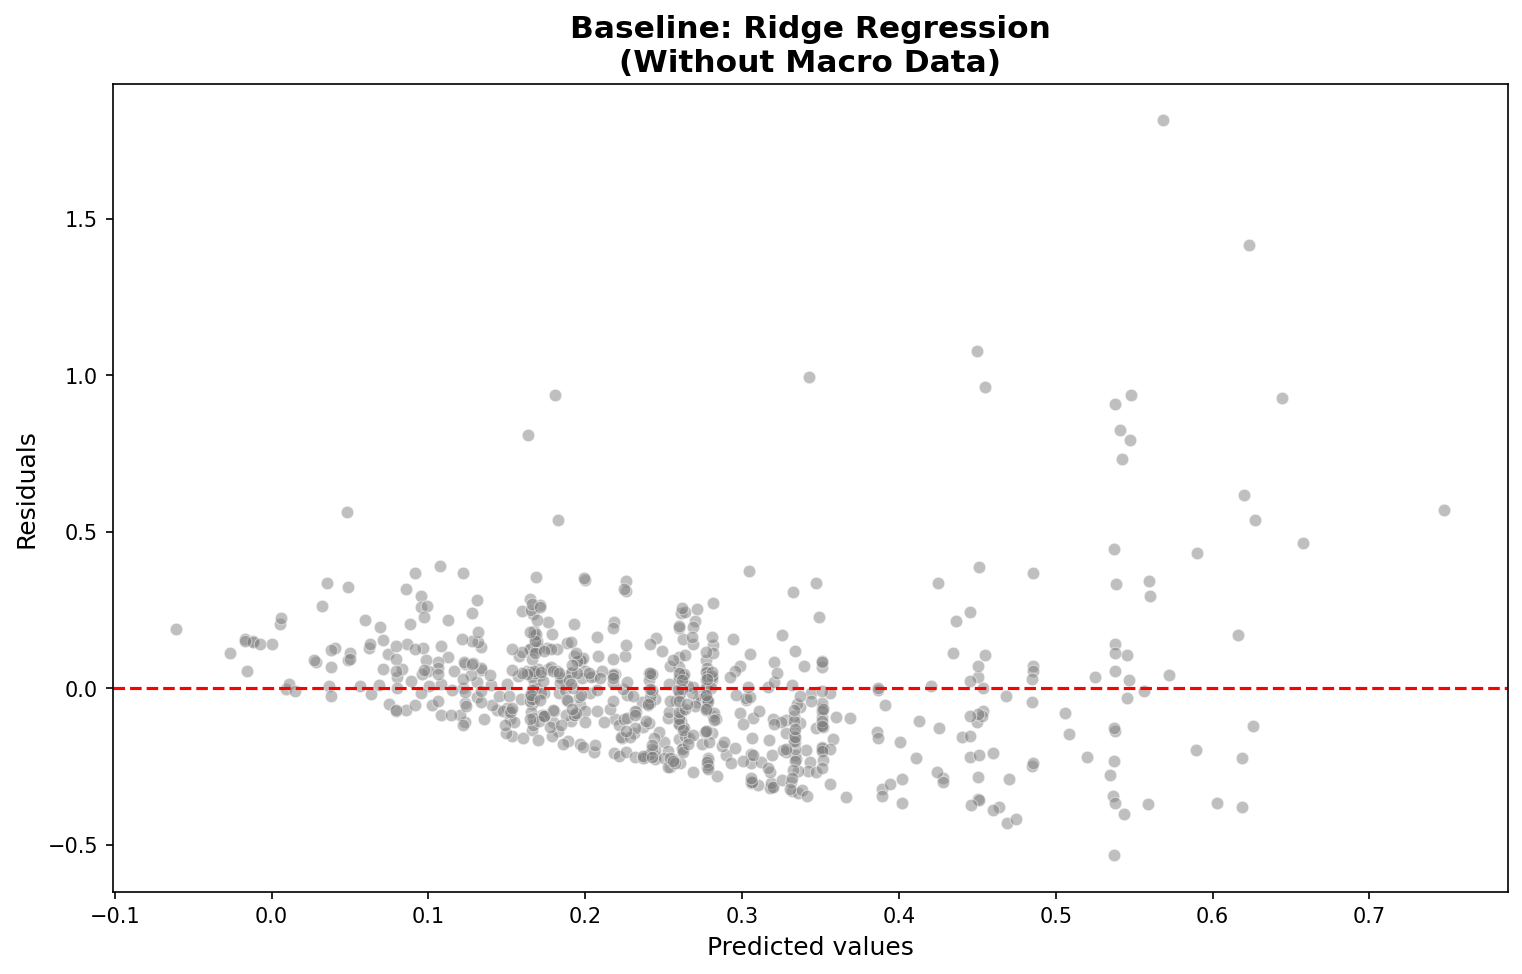

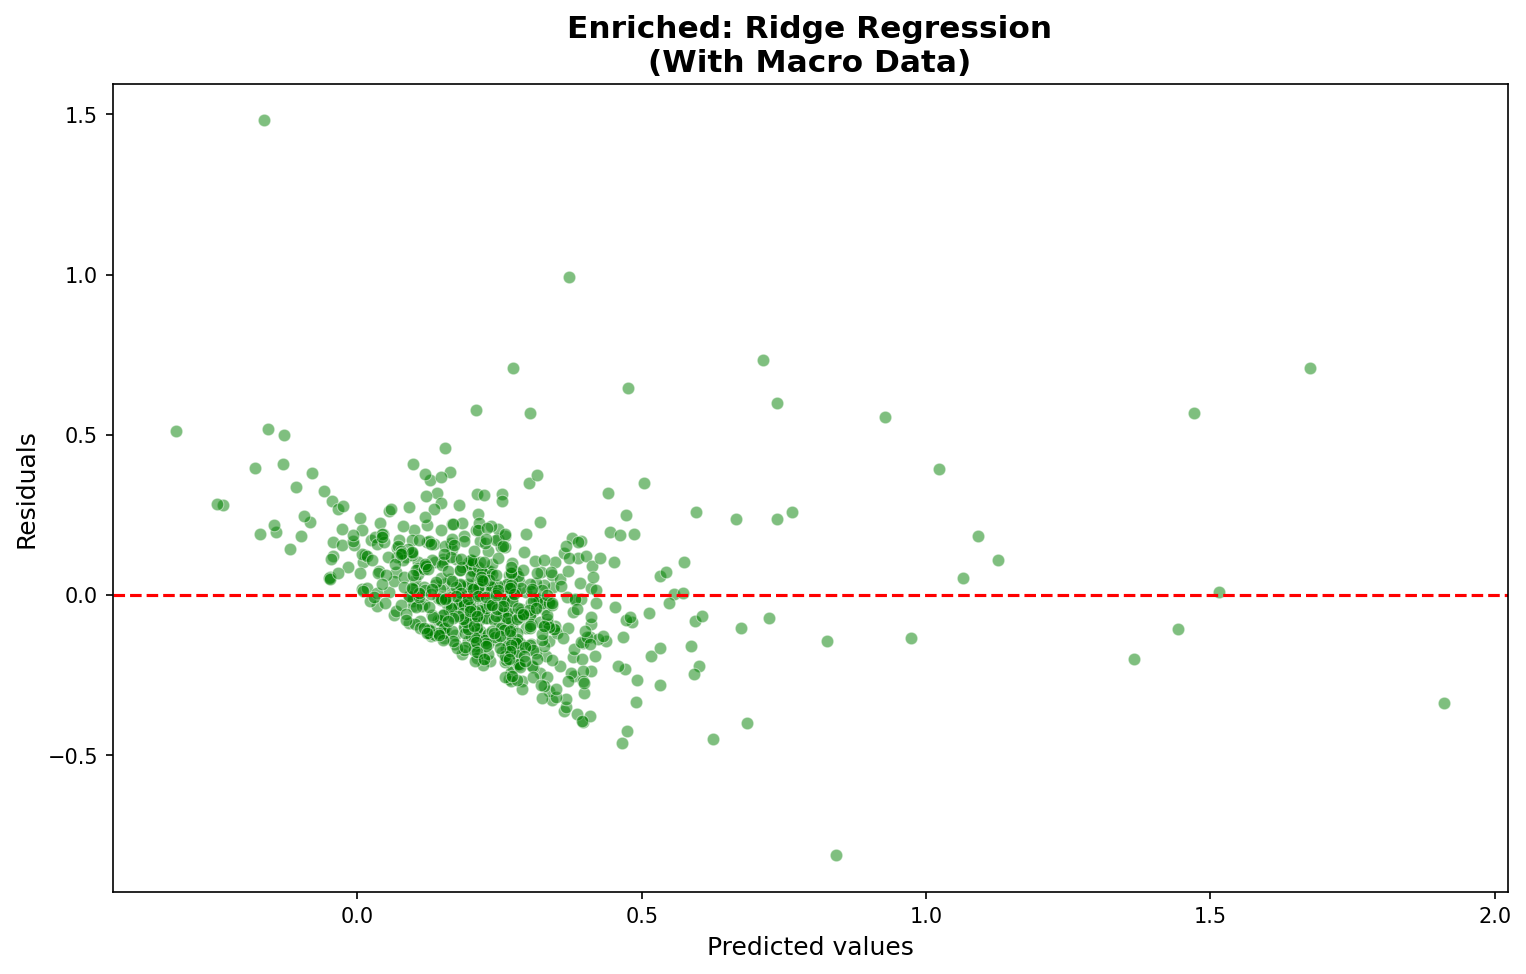

--- LASSO REGRESSION ---


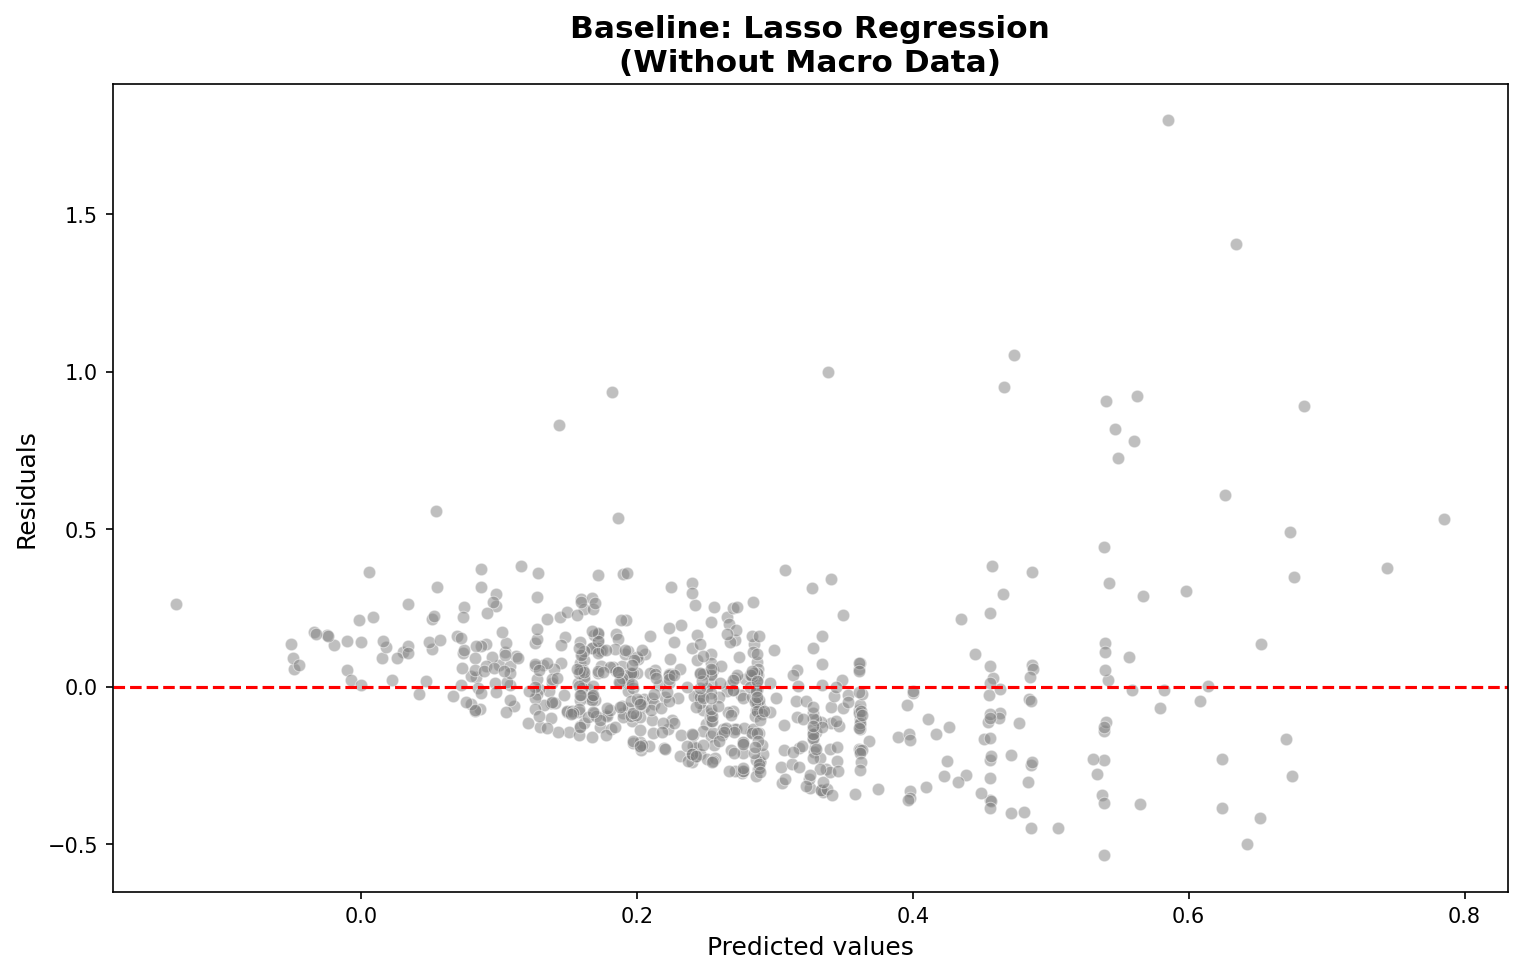

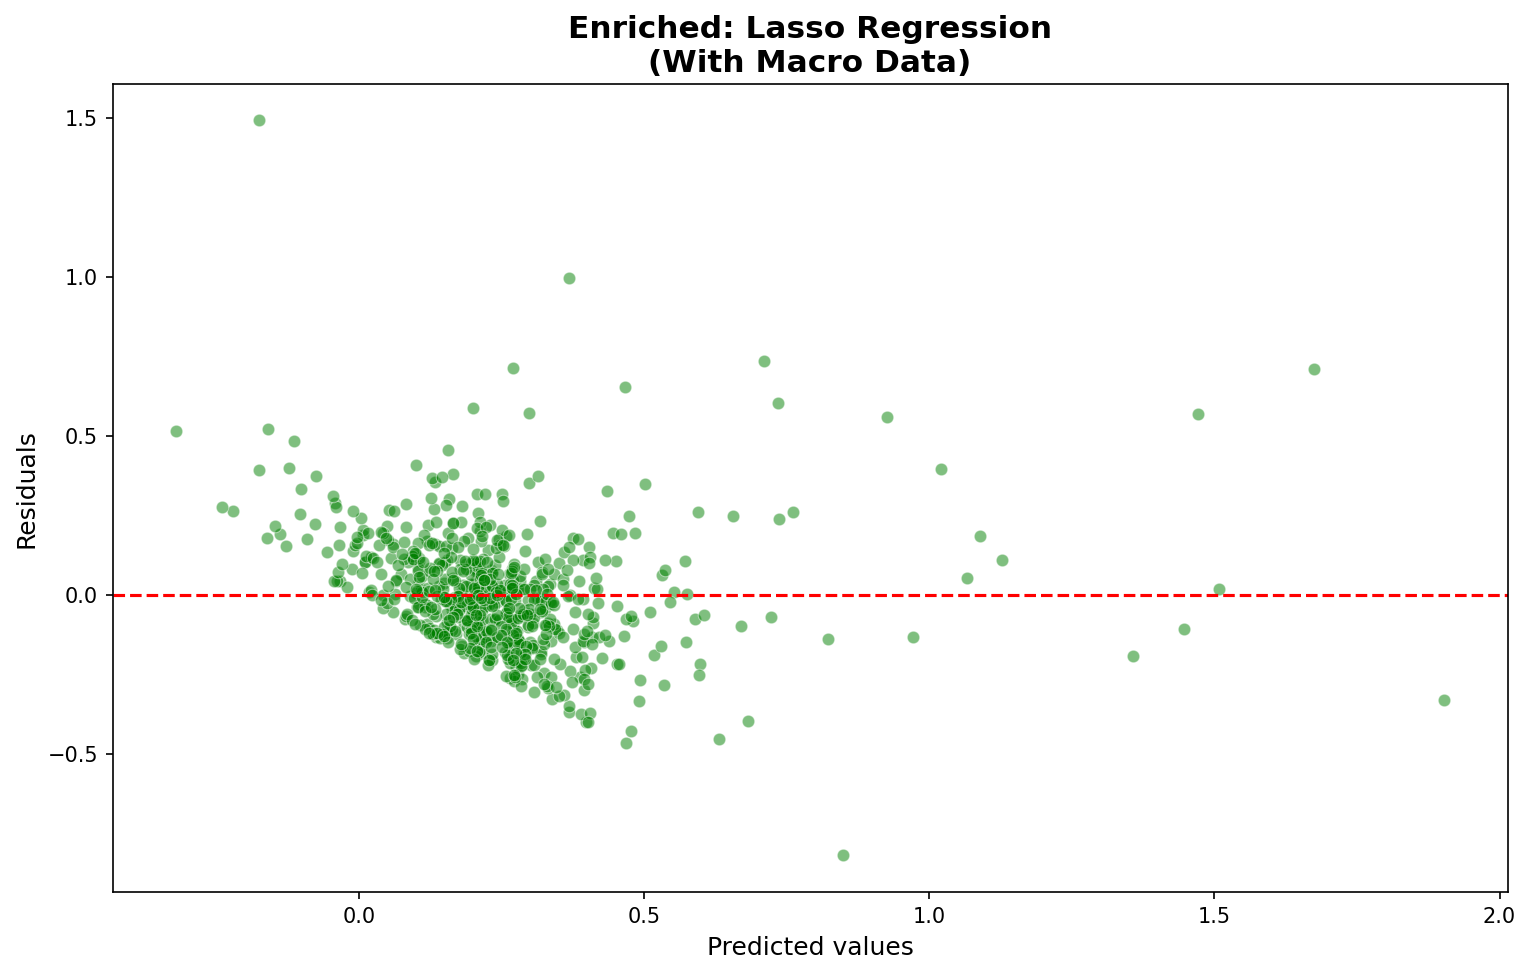

--- RANDOM FOREST ---


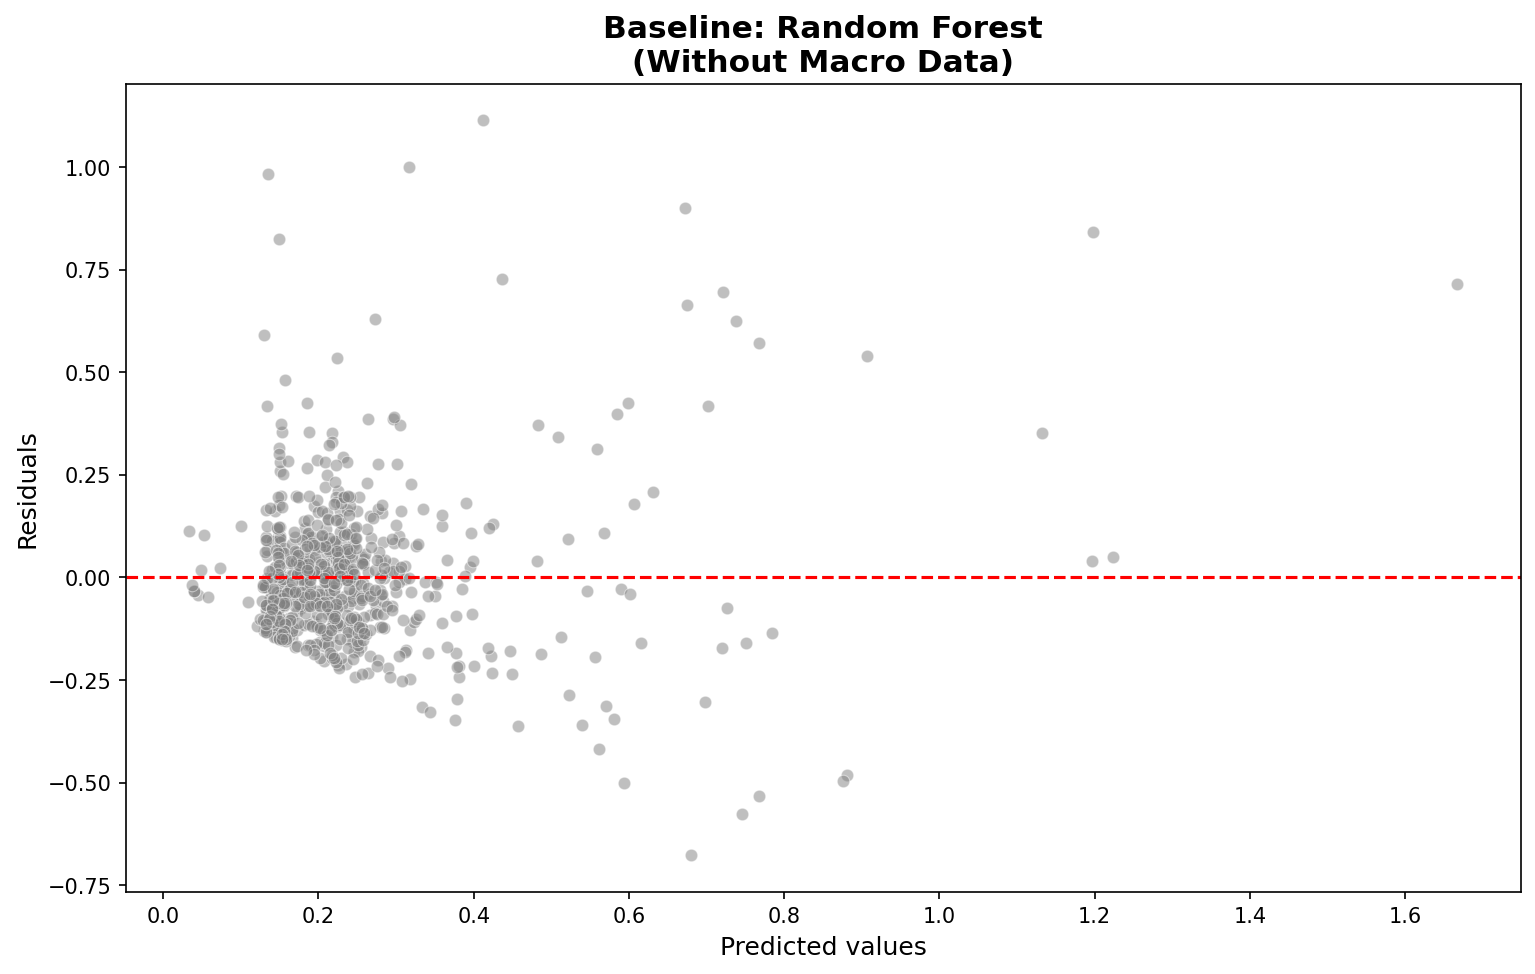

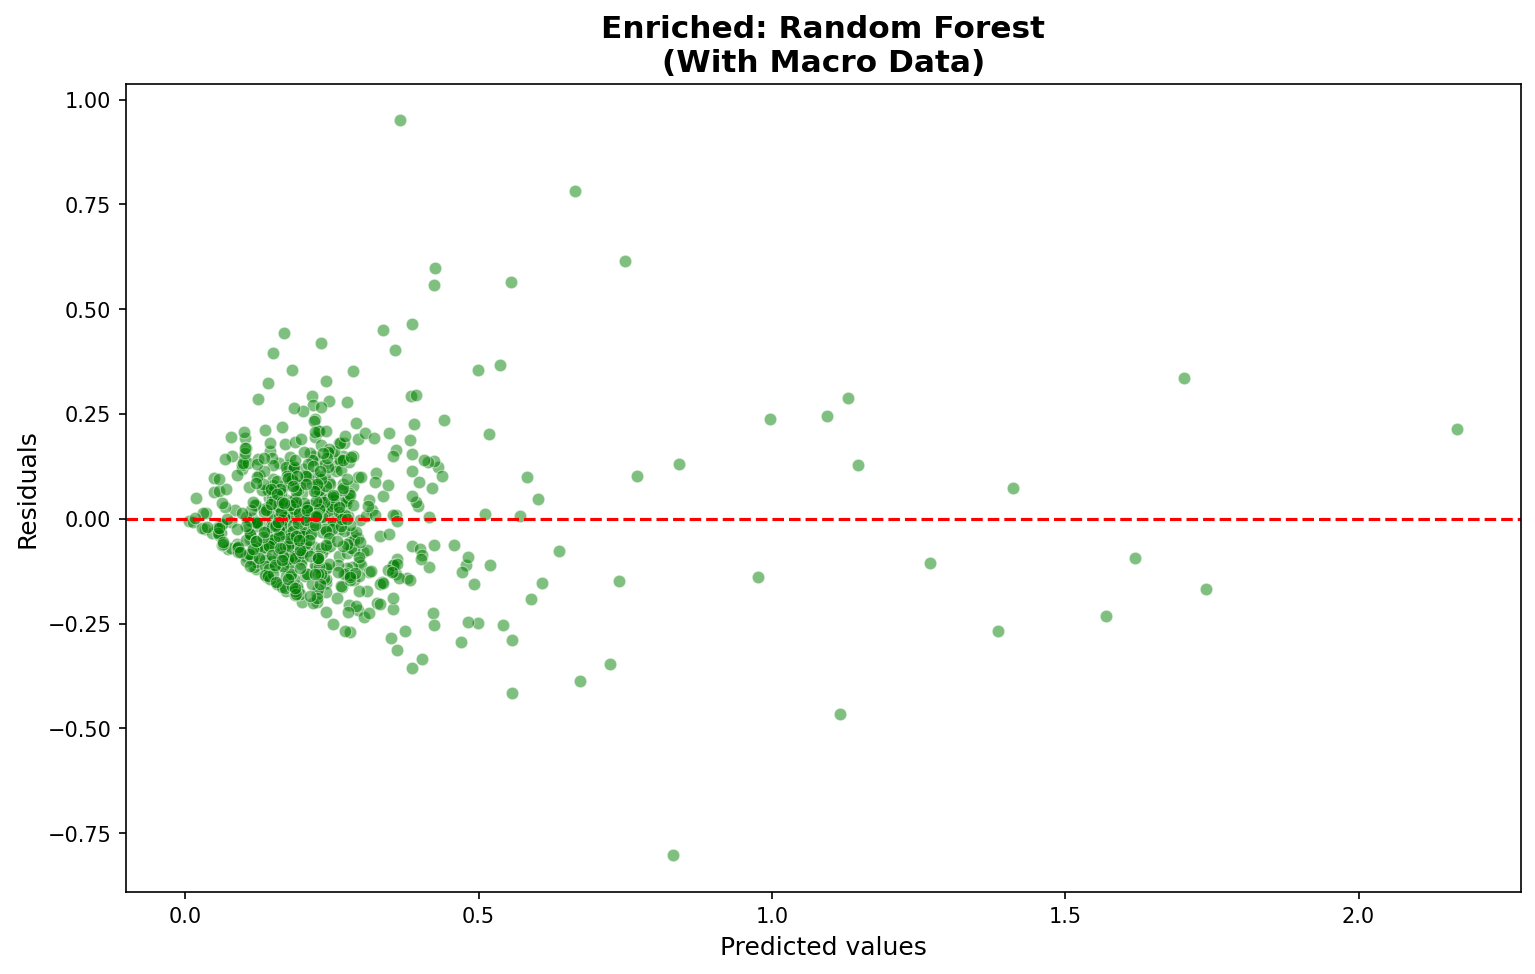

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

def plot_residuals_comparison(model_base, model_enriched, title):
    
 
    plt.figure(figsize=(12, 7), dpi=150) 
    
    y_pred_base = model_base.predict(X_test_base)
    res_base = y_test - y_pred_base
    sns.scatterplot(x=y_pred_base, y=res_base, alpha=0.5, color='gray')
    
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Baseline: {title}\n(Without Macro Data)", fontsize=15, fontweight='bold')
    plt.xlabel("Predicted values", fontsize=12)
    plt.ylabel("Residuals", fontsize=12)
    plt.show() 

   
    plt.figure(figsize=(12, 7), dpi=150)
    
    y_pred_enr = model_enriched.predict(X_test)
    res_enr = y_test - y_pred_enr
    sns.scatterplot(x=y_pred_enr, y=res_enr, alpha=0.5, color='green')
    
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Enriched: {title}\n(With Macro Data)", fontsize=15, fontweight='bold')
    plt.xlabel("Predicted values", fontsize=12)
    plt.ylabel("Residuals", fontsize=12)
    plt.show() 

# --- EXECUTION POUR LES 4 MODÈLES ---
print("--- LINEAR REGRESSION ---")
plot_residuals_comparison(lr_base, lr, "Linear Regression")

print("--- RIDGE REGRESSION ---")
plot_residuals_comparison(ridge_base, ridge, "Ridge Regression")

print("--- LASSO REGRESSION ---")
plot_residuals_comparison(lasso_base, lasso, "Lasso Regression")

print("--- RANDOM FOREST ---")
plot_residuals_comparison(rf_base, rf, "Random Forest")

The Random Forest Residual Plot shows a much tighter concentration of points around the zero line compared to the Linear Regression. This confirms that our enriched model is not only more accurate but also more stable. Most residuals are now confined within a smaller range, proving that adding macroeconomic variables effectively reduced the model's prediction errors.

c:\Users\honga\ML_Project\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


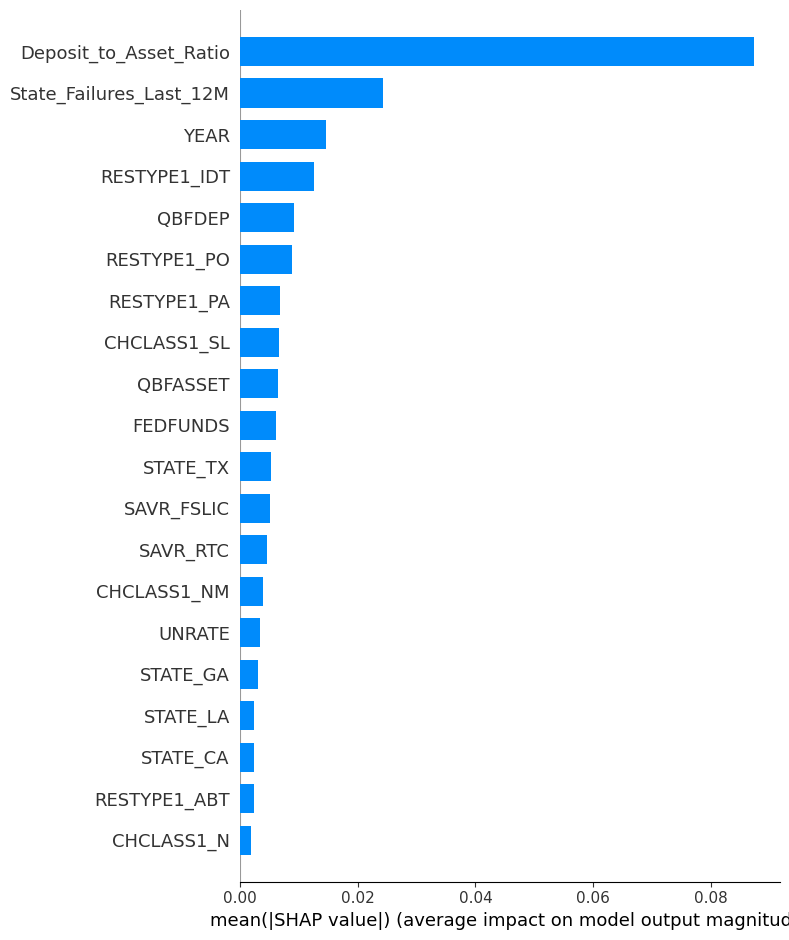

In [153]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf.best_estimator_)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")


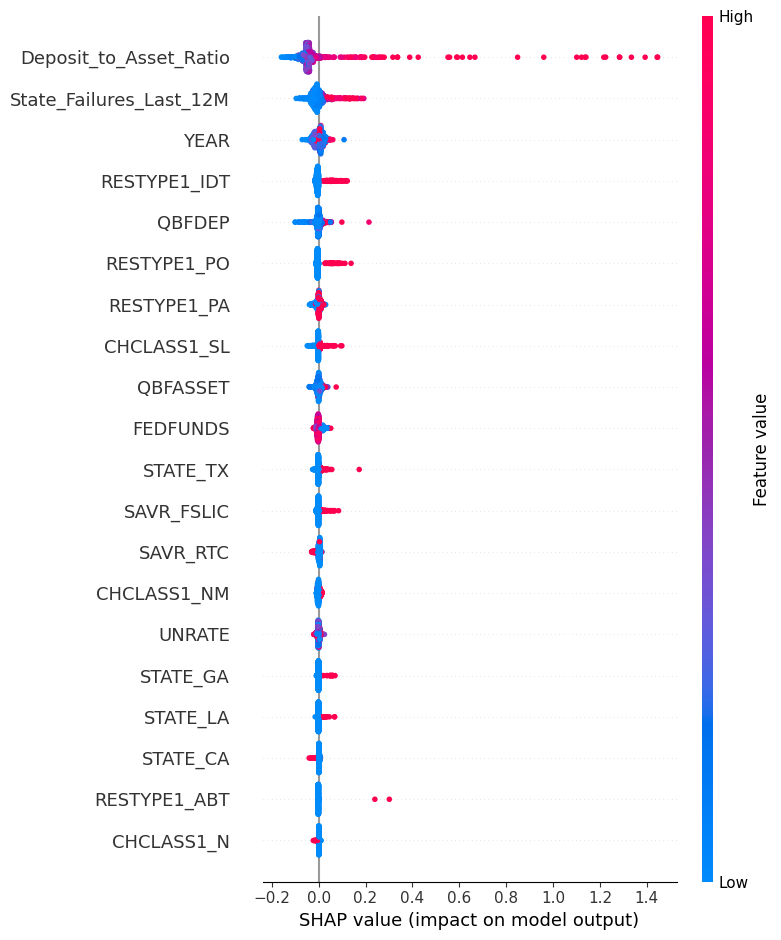

In [154]:
shap.summary_plot(shap_values, X_test)


### ✔ **Deposit_to_Asset_Ratio**  
- High ratios (red) → push LGD **up**  
- Low ratios (blue) → push LGD **down**  
This makes sense: banks with high deposit-to-asset ratios may be riskier.

### ✔ **State_Failures_Last_12M**  
- High values → increase LGD  
This means systemic stress in a state affects individual bank losses.

### ✔ **YEAR**  
- Later years may push LGD up or down depending on macro conditions.

### ✔ **Macro variables (UNRATE, FEDFUNDS)**  
They appear lower in importance but still contribute.

### ✔ **Categorical encodings (STATE_TX, RESTYPE1_PO, etc.)**  
These matter, but less than your engineered features.


# Phase 4: Binary Classification Task - Predicting High Loss Banks

In [ ]:
# Create binary classification target: 1 if LGD > 0.2, else 0
df_encoded_classification = df_encoded.copy()
df_encoded_classification['LGD_class'] = (df_encoded_classification['LGD'] > 0.2).astype(int)

print(f"Classification Target Distribution:\n{df_encoded_classification['LGD_class'].value_counts()}")
print(f"Percentage:\n{df_encoded_classification['LGD_class'].value_counts(normalize=True)}")

In [ ]:
# Prepare feature matrix and target for classification
X_class = df_encoded_classification.drop(columns=[target, 'LGD_class'])
y_class = df_encoded_classification['LGD_class']

# Split data for classification  
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Classification Dataset Shapes: {X_train_class.shape}, {X_test_class.shape}")

In [ ]:
# Initialize results for classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classification_results = []

# Logistic Regression
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_class, y_train_class)
lr_pred = lr_class.predict(X_test_class)
lr_pred_proba = lr_class.predict_proba(X_test_class)[:, 1]

classification_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test_class, lr_pred),
    'Precision': precision_score(y_test_class, lr_pred),
    'Recall': recall_score(y_test_class, lr_pred),
    'F1': f1_score(y_test_class, lr_pred),
    'AUC': roc_auc_score(y_test_class, lr_pred_proba)
})

print("Logistic Regression trained")

In [ ]:
from sklearn.model_selection import GridSearchCV

# Gradient Boosting Classifier
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
gb_class = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_class.fit(X_train_class, y_train_class)
gb_pred = gb_class.predict(X_test_class)
gb_pred_proba = gb_class.best_estimator_.predict_proba(X_test_class)[:, 1]

classification_results.append({
    'Model': 'Gradient Boosting',
    'Best Params': gb_class.best_params_,
    'Accuracy': accuracy_score(y_test_class, gb_pred),
    'Precision': precision_score(y_test_class, gb_pred),
    'Recall': recall_score(y_test_class, gb_pred),
    'F1': f1_score(y_test_class, gb_pred),
    'AUC': roc_auc_score(y_test_class, gb_pred_proba)
})

print("Gradient Boosting trained")

In [ ]:
# Random Forest Classifier
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}
rf_class = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3)
rf_class.fit(X_train_class, y_train_class)
rf_pred = rf_class.predict(X_test_class)
rf_pred_proba = rf_class.best_estimator_.predict_proba(X_test_class)[:, 1]

classification_results.append({
    'Model': 'Random Forest',
    'Best Params': rf_class.best_params_,
    'Accuracy': accuracy_score(y_test_class, rf_pred),
    'Precision': precision_score(y_test_class, rf_pred),
    'Recall': recall_score(y_test_class, rf_pred),
    'F1': f1_score(y_test_class, rf_pred),
    'AUC': roc_auc_score(y_test_class, rf_pred_proba)
})

print("Random Forest trained")

In [ ]:
# Classification Results Comparison
classification_results_df = pd.DataFrame(classification_results)
classification_results_df

In [ ]:
# Confusion Matrices and Classification Reports
from sklearn.metrics import confusion_matrix, classification_report

def plot_classification_metrics(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low Loss (≤0.2)', 'High Loss (>0.2)'],
                yticklabels=['Low Loss (≤0.2)', 'High Loss (>0.2)'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f"Confusion Matrix: {title}")
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print(f"\n{'='*60}")
    print(f"{title} - Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, 
                              target_names=['Low Loss (≤0.2)', 'High Loss (>0.2)']))

In [ ]:
import seaborn as sns
# Plot Logistic Regression
plot_classification_metrics(lr_class, X_test_class, y_test_class, "Logistic Regression")

In [ ]:
# Plot Gradient Boosting
plot_classification_metrics(gb_class.best_estimator_, X_test_class, y_test_class, "Gradient Boosting")

In [ ]:
# Plot Random Forest
plot_classification_metrics(rf_class.best_estimator_, X_test_class, y_test_class, "Random Forest")

In [ ]:
# Feature Importance for Random Forest Classification
feature_importance_class = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': rf_class.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_class, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# ROC Curves Comparison
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_class, lr_pred_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Gradient Boosting ROC
fpr_gb, tpr_gb, _ = roc_curve(y_test_class, gb_pred_proba)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_class, rf_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Classification Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Classification Task Summary

**Objective**: Predict whether a bank will have high loss (LGD > 0.2) or low loss (LGD ≤ 0.2)

**Class Distribution**:
- Low Loss (Class 0): Banks with LGD ≤ 0.2
- High Loss (Class 1): Banks with LGD > 0.2

**Models Evaluated**:
1. **Logistic Regression**: Simple baseline model
2. **Gradient Boosting**: Handles non-linear relationships with hyperparameter tuning
3. **Random Forest**: Ensemble method with best feature importance insights

**Key Metrics**:
- **Accuracy**: Overall correctness of predictions
- **Precision**: Of predicted high-loss banks, how many were actually high-loss
- **Recall**: Of actual high-loss banks, how many did the model identify  
- **F1 Score**: Balanced measure of precision and recall
- **AUC**: Ability to distinguish between classes (0.5 = random, 1.0 = perfect)

### Among all tested models, the Random Forest classifier achieved the highest performance across every evaluation metric, including Accuracy, Precision, Recall, F1, and AUC. With an AUC of 0.799, it demonstrates the strongest ability to distinguish between the two classes, making it the most reliable model for our binary classification task